# 04 · Cross-sell opportunity signals and priority tiers

> **Signals inferred from behaviour. Product ownership is unknown.** These are *Analytical Opportunity Signals*
> to prioritise conversations. They are not recommendations, eligibility checks or credit decisions (spec 6, 13, 26).

Rules (spec 13.2) use percentiles of the clean customer base [A]. The personal-loan recency condition is scaled
from 30 to 15 days to fit the 46-day window. Score per theme:
`OS_p = 100 × (0.35·V + 0.25·E + 0.30·Fit_p + 0.10·R)`. The overall score is the max over themes;
tiers are A = top 5%, B = next 15%, C = next 30%, Watch = the rest.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from c360 import db, viz
from c360.config import FIG_DIR
viz.apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 50)

In [2]:
from c360.opportunity import THEMES, THEME_LABELS
o = db.query("SELECT * FROM customer_opportunity")
c = db.query("SELECT customer_id, avg_balance::float, latest_balance::float, total_txn_value::float, txn_count, recency_days FROM customer_360")
s = db.query("SELECT customer_id, segment_id, segment_name FROM customer_segment")
o = o.merge(c, on="customer_id").merge(s, on="customer_id")
names = o.drop_duplicates("segment_id").sort_values("segment_id")["segment_name"].tolist()
thr = db.query("SELECT * FROM customer_thresholds").T.rename(columns={0: "value (Rs or score)"})
thr

,value (Rs or score)
latest_balance_p90,"197,671.55"
total_txn_value_p90,"3,526.00"
engagement_p25,25.33
avg_balance_p50,"18,461.31"
avg_balance_p75,"61,116.48"
avg_balance_p90,"202,428.07"
txn_amount_p95,"5,199.99"


## Signals by theme

In [3]:
sig = pd.DataFrame({
    "customers flagged": [o[f"sig_{t}"].sum() for t in THEMES],
    "% of customers": [100 * o[f"sig_{t}"].mean() for t in THEMES],
    "near-miss (Fit = 0.5)": [(o[f"fit_{t}"] == 0.5).sum() for t in THEMES],
    "addressable balance (Rs Cr)": [o.loc[o[f"sig_{t}"], "latest_balance"].sum() / 1e7 for t in THEMES],
}, index=[THEME_LABELS[t] for t in THEMES])
print(f"Customers with at least one signal: {o.any_signal.sum():,} ({100 * o.any_signal.mean():.1f}%)")
print(f"Addressable balance (latest balance of flagged customers): Rs {o.loc[o.any_signal, 'latest_balance'].sum() / 1e7:,.0f} crore")
sig.round(1)

Customers with at least one signal: 404,161 (48.0%)
Addressable balance (latest balance of flagged customers): Rs 8,995 crore


,customers flagged,% of customers,near-miss (Fit = 0.5),addressable balance (Rs Cr)
Investment / MF interest,126981,15.10,62342,"5,842.00"
Premium account interest,83991,10.00,83997,"7,261.90"
Credit card interest,215414,25.60,73665,"4,573.50"
Insurance interest,199478,23.70,31372,"5,166.80"
Personal loan interest (demand signal only),51725,6.10,22732,39.00
Re-engagement (service),87724,10.40,66806,"1,956.80"


## P16 · Which themes, in which segments? (share of segment flagged)

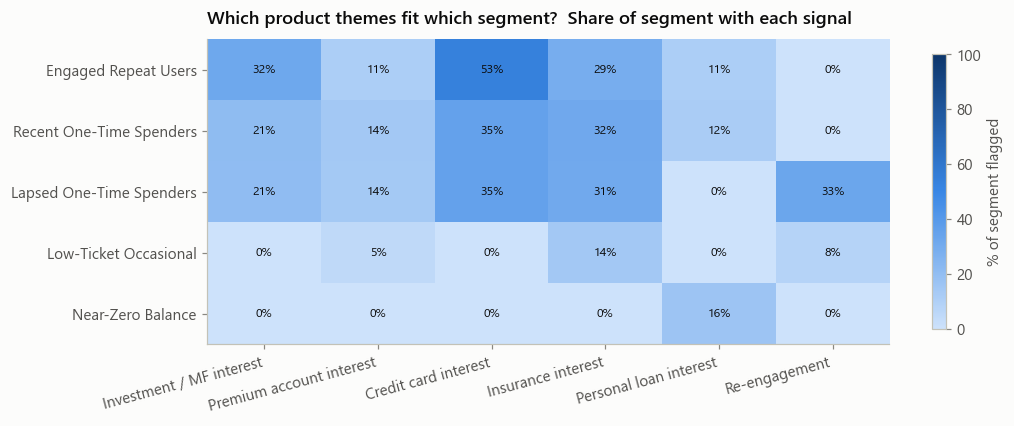

In [4]:
rate = pd.DataFrame({THEME_LABELS[t].split(" (")[0]: o.groupby("segment_name")[f"sig_{t}"].mean() * 100 for t in THEMES}).loc[names]
from matplotlib.colors import LinearSegmentedColormap
seq = LinearSegmentedColormap.from_list("blue", [viz.BLUE[100], viz.BLUE[400], viz.BLUE[700]])
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(rate.values, cmap=seq, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(rate.shape[1]), rate.columns, rotation=15, ha="right"); ax.set_yticks(range(len(names)), names)
ax.grid(False)
for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        ax.text(j, i, f"{rate.values[i, j]:.0f}%", ha="center", va="center", fontsize=8,
                color="white" if rate.values[i, j] > 55 else viz.INK)
fig.colorbar(im, ax=ax, label="% of segment flagged", shrink=0.9)
ax.set_title("Which product themes fit which segment?  Share of segment with each signal")
viz.save(fig, "P16_theme_by_segment"); fig

**What we found.** Credit-card interest is the broadest signal (25.6% of customers) and is concentrated in Engaged Repeat Users (53% of the segment). Investment and insurance signals sit mainly in the three mid-to-high-value segments. Re-engagement appears almost only in Lapsed One-Time Spenders (33%). Near-Zero Balance customers carry only the personal-loan demand signal (16%), and Low-Ticket Occasional carry mostly insurance (14%).

**Why it matters.** The segments and the product signals line up, so each segment gets a short list of conversations rather than every product.

**What a manager should do.** Lead with cards and investments for Engaged Repeat Users, and with a re-engagement call before any sale for Lapsed One-Time Spenders. Treat the personal-loan flag in Near-Zero Balance as a demand signal only: no eligibility is implied.

## P17 · Score distribution by tier

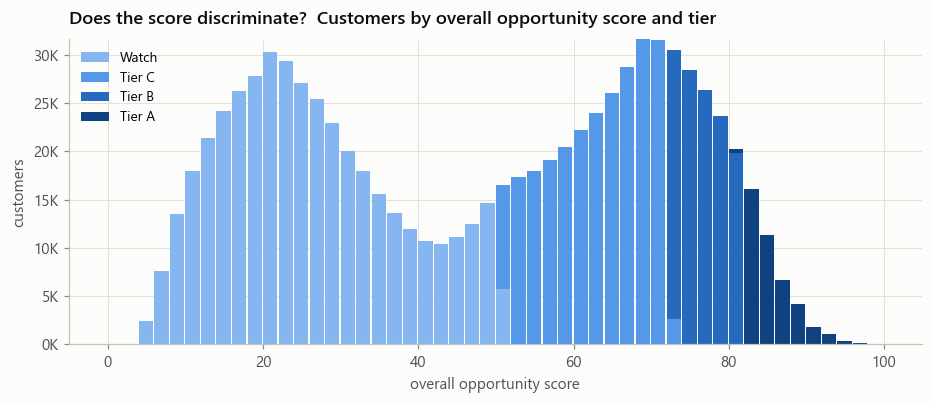

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.6))
bins = np.linspace(0, 100, 51)
bottom = np.zeros(len(bins) - 1)
for t in ["Watch", "C", "B", "A"]:
    h, _ = np.histogram(o.loc[o.tier == t, "overall_score"], bins=bins)
    ax.bar(bins[:-1], h, width=np.diff(bins) * 0.92, align="edge", bottom=bottom, color=viz.TIER_COLORS[t], label=f"Tier {t}" if t != "Watch" else "Watch")
    bottom += h
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.set_xlabel("overall opportunity score"); ax.set_ylabel("customers"); ax.legend(loc="upper left")
ax.set_title("Does the score discriminate?  Customers by overall opportunity score and tier")
viz.save(fig, "P17_score_distribution"); fig

In [6]:
tiers = o.groupby("tier").agg(customers=("customer_id", "size"), min_score=("overall_score", "min"),
                              max_score=("overall_score", "max"), with_signal=("any_signal", "mean"),
                              addressable_cr=("latest_balance", lambda s: s[o.loc[s.index, "any_signal"]].sum() / 1e7)).loc[["A", "B", "C", "Watch"]]
tiers["share %"] = 100 * tiers.customers / len(o); tiers["with_signal"] *= 100
ev = pd.crosstab(o.tier, o.evidence_level, normalize="index").loc[["A", "B", "C", "Watch"], ["High", "Medium", "Low"]] * 100
tiers.join(ev.add_prefix("evidence % ")).round(1)

,customers,min_score,max_score,with_signal,addressable_cr,share %,evidence % High,evidence % Medium,evidence % Low
tier,,,,,,,,,
A,42077,82.00,99.50,100.00,"1,721.00",5.00,22.70,52.40,24.90
B,126231,72.20,82.00,100.00,"3,718.20",15.00,2.40,30.40,67.10
C,252463,50.70,72.20,87.10,"3,513.20",30.00,0.70,9.90,89.30
Watch,420772,4.40,50.70,3.80,42.80,50.00,0.40,6.70,92.90


In [7]:
pd.crosstab(o.segment_name, o.tier).loc[names, ["A", "B", "C", "Watch"]]

tier,A,B,C,Watch
segment_name,,,,
Engaged Repeat Users,31607,41448,26278,27135
Recent One-Time Spenders,10470,68733,62905,60885
Lapsed One-Time Spenders,0,15909,115147,83902
Low-Ticket Occasional,0,141,38606,178394
Near-Zero Balance,0,0,9527,70456


**What we found.** Scores are bimodal: one mode around 20 (customers with no fitting rule) and one around 70 (at least one rule met). Tier A starts at a score of 82, Tier B at 72 and Tier C at 51. Every Tier A and B customer has at least one full signal. Tier A is led by Engaged Repeat Users (31,607 of 42,077) and Recent One-Time Spenders (10,470). Lapsed, Low-Ticket and Near-Zero customers never reach Tier A, because recency and engagement carry 35% of the score.

**Why it matters.** The score separates customers clearly, and the top tier holds better-evidenced customers: 75% of Tier A have two or more transactions, against 7% of the Watch tier.

**What a manager should do.** Work Tier A first (42,077 customers, Rs 1,721 crore addressable balance) and review weekly; use Tier B for campaigns. **Caveat:** 48% of customers carry at least one signal, which the KPI dictionary flags as broad. The credit-card and insurance rules (P60/P40 and age-band thresholds) are the main reason, so tightening them is the first tuning step once real response data exists.

## Sensitivity of the ranking to the weights (FR-031, T-11)

In [8]:
db.query('SELECT * FROM opportunity_sensitivity')

,scenario,w_V,w_E,w_Fit,w_R,top1000_overlap_pct,spearman_vs_base
0,V +10 pts,0.41,0.23,0.27,0.09,92.70,1.00
1,V -10 pts,0.28,0.28,0.33,0.11,90.10,1.00
2,E +10 pts,0.32,0.32,0.27,0.09,88.30,1.00
3,E -10 pts,0.39,0.17,0.33,0.11,86.70,1.00
4,Fit +10 pts,0.32,0.23,0.36,0.09,100.00,1.00
5,Fit -10 pts,0.39,0.28,0.22,0.11,100.00,1.00
6,R +10 pts,0.32,0.23,0.27,0.18,90.00,0.99
7,R -10 pts,0.39,0.28,0.33,0.00,83.70,0.99


**What we found.** Moving any weight by ±10 points (then renormalising) keeps 84-100% of the top 1,000 customers, and the rank correlation with the base ranking stays at 0.99 or above. The ranking is least sensitive to the Fit weight (100% overlap) and most sensitive to removing recency entirely (R -10 pts → 83.7%).

**Why it matters.** The judgemental weights (AS-08) do not drive the priority list; the top of the list is robust.

**What a manager should do.** Trust the top-1,000 list for outreach planning; revisit the weights only when campaign outcome data is available.

## Priority list (Page 4 preview, masked IDs)

In [9]:
o.sort_values("priority_rank").head(15)[["priority_rank", "masked_id", "tier", "overall_score", "driving_theme_label", "segment_name", "evidence_level", "reason"]]

,priority_rank,masked_id,tier,overall_score,driving_theme_label,segment_name,evidence_level,reason
632043,1,C4***330,A,99.46,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 593,183 (top 3%), 4 txns, last ..."
631755,2,C8***947,A,99.44,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 725,079 (top 3%), 4 txns, last ..."
629592,3,C6***360,A,99.35,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 865,086 (top 2%), 6 txns, last ..."
627732,4,C1***421,A,99.28,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 647,950 (top 3%), 4 txns, last ..."
627736,5,C3***087,A,99.28,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 591,430 (top 3%), 5 txns, last ..."
634306,6,C5***137,A,99.17,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 830,086 (top 2%), 4 txns, last ..."
622163,7,C4***542,A,99.04,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 268,816 (top 8%), 4 txns, last ..."
631242,8,C6***460,A,99.04,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 1,023,849 (top 2%), 5 txns, las..."
621967,9,C1***368,A,99.04,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 502,789 (top 4%), 4 txns, last ..."
630863,10,C5***648,A,99.03,Investment / MF interest,Engaged Repeat Users,High,"avg balance Rs 425,154 (top 5%), 4 txns, last ..."


## Reconciliation: Python vs SQL (FR-038, T-15)

In [10]:
py = {
    "Total Customers": len(o), "Total Transactions": int(o.txn_count.sum()), "Total Txn Value": o.total_txn_value.sum(),
    "Avg Balance": o.avg_balance.mean(), "Median Balance": o.avg_balance.median(),
    "Opportunity Count": int(o.any_signal.sum()), "Tier A Customers": int((o.tier == "A").sum()),
    "Addressable Balance": o.loc[o.any_signal, "latest_balance"].sum(),
}
sqlk = db.query("SELECT kpi, sql_value::float AS sql FROM kpi_reconciliation").set_index("kpi")
rec = sqlk.join(pd.Series(py, name="python"), how="inner")
rec["variance"] = (rec["python"] - rec["sql"]).round(4)
rec["status"] = np.where(rec["variance"].abs() < 0.01, "PASS", "CHECK")
rec

,sql,python,variance,status
kpi,,,,
Total Customers,"841,543.00","841,543.00",0.00,PASS
Total Transactions,"988,947.00","988,947.00",0.00,PASS
Total Txn Value,"1,554,774,113.48","1,554,774,113.48",-0.00,PASS
Avg Balance,"114,676.57","114,676.57",0.00,PASS
Median Balance,"18,461.31","18,461.31",0.00,PASS
Opportunity Count,"404,161.00","404,161.00",0.00,PASS
Tier A Customers,"42,077.00","42,077.00",0.00,PASS
Addressable Balance,"89,952,696,004.17","89,952,696,004.17",0.00,PASS


**Reconciliation.** Every headline KPI computed in Python equals the SQL reference table `kpi_reconciliation` (variance 0). The same table is the reference for the Power BI cards (T-12) and the Excel MIS (T-14), which closes FR-038 / RO-4.